In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
"""Analysis script to compare results from different models."""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_results(results_dir, classifier_names, dataset_names, alphas, 
                 temperatures, num_iterations=5):
    """
    Load all experiment results.
    
    Args:
        results_dir: Root directory (e.g., './Results_PyTorch/results')
        classifier_names: List like ['teacher', 'student_kd', 'student_alone']
        dataset_names: List of dataset names
        alphas: List of alpha values for KD (default: [0.3])
        temperatures: List of temperature values for KD (default: [10])
        num_iterations: Number of iterations (default: 5)
    
    Returns:
        DataFrame with all results
    """
    results = []
    
    for classifier in classifier_names:
        for dataset in dataset_names:
            for iteration in range(1, num_iterations + 1):
                
                # Handle student_kd with alpha/temperature
                if classifier == 'student_kd':
                    for alpha in alphas:
                        for temp in temperatures:
                            path = os.path.join(
                                results_dir, classifier, 
                                f'alpha_{alpha}', f'temperature_{temp}',
                                f'UCRArchive_2018_itr_{iteration}', 
                                dataset, 'df_metrics.csv'
                            )
                            
                            if os.path.exists(path):
                                df = pd.read_csv(path)
                                df['classifier'] = classifier
                                df['dataset'] = dataset
                                df['iteration'] = iteration
                                df['alpha'] = alpha
                                df['temperature'] = temp
                                results.append(df)
                
                # Handle teacher/student_alone (no alpha/temp)
                else:
                    path = os.path.join(
                        results_dir, classifier,
                        f'UCRArchive_2018_itr_{iteration}', 
                        dataset, 'df_metrics.csv'
                    )
                    
                    if os.path.exists(path):
                        df = pd.read_csv(path)
                        df['classifier'] = classifier
                        df['dataset'] = dataset
                        df['iteration'] = iteration
                        df['alpha'] = np.nan
                        df['temperature'] = np.nan
                        results.append(df)
    
    if not results:
        print("No results found!")
        return None
    
    df_all = pd.concat(results, ignore_index=True)
    print(f"Loaded {len(df_all)} results")
    return df_all


In [5]:
# Configuration
RESULTS_DIR = os.path.join(os.getcwd(), 'Results_FCN/results')
CLASSIFIER_NAMES = ['student_kd', ]
DATASET_NAMES = ['ArrowHead', 'Wine', 'FreezerSmallTrain', 'OliveOil',   'Car', 'NonInvasiveFetalECGThorax2', 
                    'TwoPatterns', 'InsectWingbeatSound', 'BeetleFly', 'Yoga', 'InlineSkate', 'FaceAll',
                    'EOGVerticalSignal', 'Ham', 'MoteStrain', 'ProximalPhalanxTW', 'WordSynonyms', 'Lightning7', 
                    'GunPointOldVersusYoung', 'Earthquakes', 'FordB',]

ALPHAS = [0.1, 0.3, 0.5, 0.7, 0.9]
TEMPERATURES = [4, 10, 16, 32]
NUM_ITERATIONS = 5

# Run analysis
res_student_df = load_results(RESULTS_DIR, CLASSIFIER_NAMES, DATASET_NAMES, 
                    ALPHAS, TEMPERATURES, NUM_ITERATIONS)



Loaded 2100 results


In [4]:
fin_tch_df = teacher_df.groupby('dataset').mean(['accuracy']).reset_index()

In [6]:
fin_std_df = res_student_df.groupby(['dataset', 'alpha', 'temperature']).mean('accuracy').reset_index()

In [7]:
fin_std_df

,dataset,alpha,temperature,accuracy,precision,recall,duration,iteration
0,ArrowHead,0.1,4,0.768000,0.805262,0.779364,2.870674,3.0
1,ArrowHead,0.1,10,0.770286,0.806237,0.779546,2.753719,3.0
2,ArrowHead,0.1,16,0.772571,0.803613,0.779728,2.807923,3.0
3,ArrowHead,0.1,32,0.754286,0.775756,0.760769,2.941154,3.0
4,ArrowHead,0.3,4,0.757714,0.792668,0.765710,2.838182,3.0
...,...,...,...,...,...,...,...,...
415,Yoga,0.7,32,0.843533,0.845826,0.845730,14.325250,3.0
416,Yoga,0.9,4,0.849067,0.850878,0.851488,14.507957,3.0
417,Yoga,0.9,10,0.847200,0.850582,0.850195,14.436412,3.0
418,Yoga,0.9,16,0.845733,0.849423,0.849361,14.588100,3.0


In [8]:
fin_tch_df.rename(columns={'accuracy': 'accuracy_tch'}, inplace=True)


In [ ]:
ALPHAS = [0.1, 0.3, 0.5, 0.7, 0.9]
TEMPERATURES = [4, 10, 16, 32]

columns = ['alpha', 'temperature', 'wins', 'ties', 'losses']
res_hyp_df = pd.DataFrame(columns=columns)
for alpha in ALPHAS:
    for temp in TEMPERATURES:
        rows = [alpha, temp]
        tmp_df = fin_std_df[(fin_std_df['alpha'] == alpha) & (fin_std_df['temperature'] == temp)]
        tmp_df.rename(columns={'accuracy': 'accuracy_kd'}, inplace=True)
        merge_df = pd.merge(fin_tch_df[['dataset', 'accuracy_tch']], tmp_df[['dataset', 'accuracy_kd']], on='dataset')
        wins = merge_df[merge_df['accuracy_kd'] > merge_df['accuracy_tch']].shape[0]
        ties = merge_df[merge_df['accuracy_kd'] == merge_df['accuracy_tch']].shape[0]
        losses = merge_df[merge_df['accuracy_kd'] < merge_df['accuracy_tch']].shape[0]
        print(f'wins: {wins}, ties: {ties}, losses: {losses}')
        rows += [wins, ties, losses]
        
        res_hyp_df = pd.concat(
            [res_hyp_df, pd.DataFrame([rows], columns=columns)],
            ignore_index=True
        )        
    #     break
    # break
        

In [ ]:
# res_hyp_df.to_csv('results_inception.csv', index=False)

In [ ]:
# res_hyp_df.to_csv('results_fcn.csv', index=False)


In [29]:
res_inc_df = pd.read_csv('results_fcn.csv')

In [30]:
res_inc_df

,alpha,temperature,wins,ties,losses
0,0.1,4,6,0,15
1,0.1,10,7,0,14
2,0.1,16,3,1,17
3,0.1,32,6,0,15
4,0.3,4,6,0,15
5,0.3,10,4,0,17
6,0.3,16,6,0,15
7,0.3,32,6,0,15
8,0.5,4,5,1,15
9,0.5,10,4,0,17


In [31]:
tmp_df = res_inc_df[res_inc_df['temperature'] != 4]
tmp_df

,alpha,temperature,wins,ties,losses
1,0.1,10,7,0,14
2,0.1,16,3,1,17
3,0.1,32,6,0,15
5,0.3,10,4,0,17
6,0.3,16,6,0,15
7,0.3,32,6,0,15
9,0.5,10,4,0,17
10,0.5,16,7,0,14
11,0.5,32,6,0,15
13,0.7,10,5,1,15


In [32]:
t_10 = tmp_df[tmp_df['temperature'] == 10]['wins'].to_list()
t_16 = tmp_df[tmp_df['temperature'] == 16]['wins'].to_list()
t_32 = tmp_df[tmp_df['temperature'] == 32]['wins'].to_list()

In [33]:
print('t_10: ', t_10)
print('t_16: ', t_16)
print('t_32: ', t_32)


t_10:  [7, 4, 4, 5, 6]
t_16:  [3, 6, 7, 6, 5]
t_32:  [6, 6, 6, 7, 6]


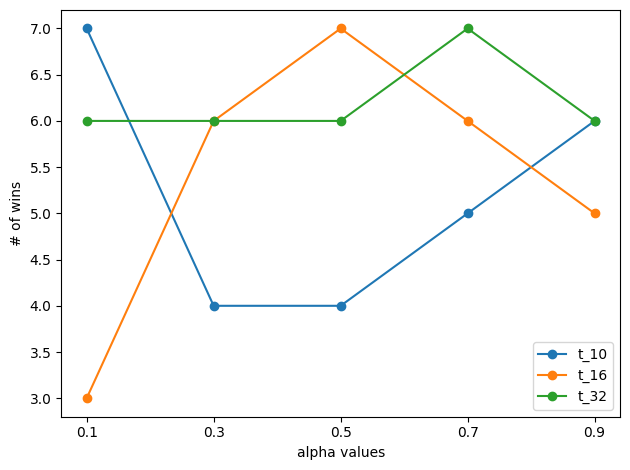

In [ ]:
import matplotlib.pyplot as plt

data = {
    "t_10": [14, 14, 13, 13, 13],
    "t_16": [12, 10, 11, 13, 13],
    "t_32": [11, 13, 14, 12, 12],
}

x = [0.1, 0.3, 0.5, 0.7, 0.9]  # index of each value inside the list

for label, y in data.items():
    plt.plot(x, y, marker="o", linewidth=1.5, label=label)  # line + dots

plt.xticks(x)
plt.xlabel("alpha values")
plt.ylabel("# of wins")
plt.legend()
plt.tight_layout()
plt.show()


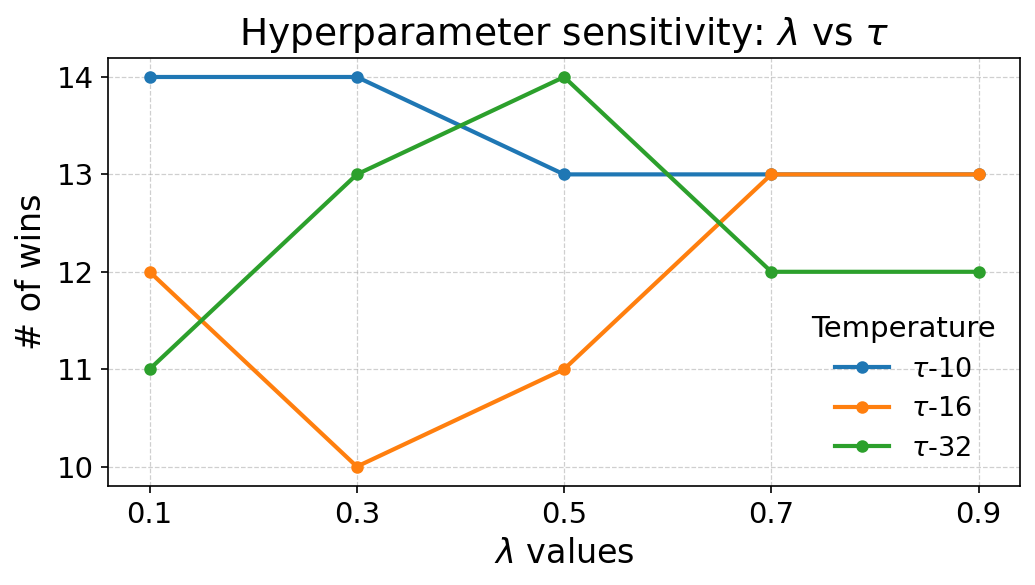

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


data = {
    r"$\tau$-10": [14, 14, 13, 13, 13],
    r"$\tau$-16": [12, 10, 11, 13, 13],
    r"$\tau$-32": [11, 13, 14, 12, 12],

}

alphas = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

# ---- Font sizes (edit here) ----
TITLE_FS = 18
LABEL_FS = 16
TICK_FS  = 14
LEGEND_FS = 13
LEGEND_TITLE_FS = 14

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for label in sorted(data.keys()):
    y = np.array(data[label])
    ax.plot(alphas, y, marker="o", linewidth=2, markersize=5, label=label)

ax.set_title(r"Hyperparameter sensitivity: $\lambda$ vs $\tau$", fontsize=TITLE_FS)
ax.set_xlabel(r"$\lambda$ values", fontsize=LABEL_FS)
ax.set_ylabel("# of wins", fontsize=LABEL_FS)

ax.set_xticks(alphas)
ax.set_xticklabels([f"{a:.1f}" for a in alphas], fontsize=TICK_FS)

ax.tick_params(axis="y", labelsize=TICK_FS)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

leg = ax.legend(
    title="Temperature",
    frameon=False,
    fontsize=LEGEND_FS,
    title_fontsize=LEGEND_TITLE_FS
)

fig.tight_layout()
fig.savefig("alpha_sensitivity_inception.pdf", bbox_inches="tight")

plt.show()
